## 1. Install & Import Libraries

In [1]:
# install libraries
!pip install ultralytics roboflow matplotlib opencv-python-headless pillow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.2/249.2 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 59.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 76.1 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.18
    Uninstalling idna-3.18:
      Successfully uninstalled idna-3.18


In [2]:
# mount Google Drive (for Google Colab)
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# import libraries
import os
import glob
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import cv2
from collections import Counter

## 2. GPU Check

In [4]:
# check if GPU is available
import torch
print('GPU:', 'Active' if torch.cuda.is_available() else 'Not available')
if torch.cuda.is_available():
    print('GPU Name:', torch.cuda.get_device_name(0))

GPU: Active
GPU Name: Tesla T4


## 3. Load Dataset

In [5]:
# Configuration (Change configuration only in this cell)
USE_LOCAL = True

# Roboflow Configuration (USE_LOCAL = False)
ROBOFLOW_API_KEY = "YOUR_API_KEY"
ROBOFLOW_WORKSPACE = "ayu-asipq"
ROBOFLOW_PROJECT = "calory"
ROBOFLOW_VERSION = 1

# Local Configuration (USE_LOCAL = True)
LOCAL_DATASET_DIR = "/content/drive/MyDrive/07. AI/object_detection_calory/Calory.v1i.yolov12"

In [6]:
# Load dataset based on the configuration
if USE_LOCAL:
    DATASET_DIR = LOCAL_DATASET_DIR
    print('Using local dataset:', DATASET_DIR)
else:
    from roboflow import Roboflow
    rf = Roboflow(api_key=ROBOFLOW_API_KEY)
    project = rf.workspace(ROBOFLOW_WORKSPACE).project(ROBOFLOW_PROJECT)
    version = project.version(ROBOFLOW_VERSION)
    dataset = version.download("yolov12")
    DATASET_DIR = dataset.location
    print('Dataset downloaded to:', DATASET_DIR)

Using local dataset: /content/drive/MyDrive/07. AI/object_detection_calory/Calory.v1i.yolov12


## 4. Class & Calorie Definition

In [7]:
# class names based on data.yaml from Roboflow
CLASS_NAMES = [
    'Ayam Goreng -260 kal per 100 gr-',
    'Capcay -67 kal per 100gr-',
    'Nasi -129 kal per 100gr-',
    'Sayur bayam -36 kal per 100gr-',
    'Sayur kangkung -98 kal per 100gr-',
    'Sayur sop -22 kal per 100gr-',
    'Tahu -80 kal per 100 gr-',
    'Telur Dadar -93 kal per 100gr-',
    'Telur Mata Sapi -110kal1butir-',
    'Telur Rebus -78kal 1butir-',
    'Tempe -225 kal per 100 gr-',
    'Tumis buncis -65 kal per 100gr-',
    'food-z7P4'
]

# calories per class (in kcal)
CALORY_MAP = {
    0: 260,  # Ayam Goreng
    1: 67,   # Capcay
    2: 129,  # Nasi
    3: 36,   # Sayur Bayam
    4: 98,   # Sayur Kangkung
    5: 22,   # Sayur Sop
    6: 80,   # Tahu
    7: 93,   # Telur Dadar
    8: 110,  # Telur Mata Sapi
    9: 78,   # Telur Rebus
    10: 225, # Tempe
    11: 65,  # Tumis Buncis
    12: 0    # other food
}

# short names for display
SHORT_NAMES = {
    0: 'Ayam Goreng',
    1: 'Capcay',
    2: 'Nasi',
    3: 'Sayur Bayam',
    4: 'Sayur Kangkung',
    5: 'Sayur Sop',
    6: 'Tahu',
    7: 'Telur Dadar',
    8: 'Telur Mata Sapi',
    9: 'Telur Rebus',
    10: 'Tempe',
    11: 'Tumis Buncis',
    12: 'Food (Other)'
}

print(f'Total classes: {len(CLASS_NAMES)}')
for i, name in SHORT_NAMES.items():
    print(f'  [{i}] {name} - {CALORY_MAP[i]} kcal')

Total classes: 13
  [0] Ayam Goreng - 260 kcal
  [1] Capcay - 67 kcal
  [2] Nasi - 129 kcal
  [3] Sayur Bayam - 36 kcal
  [4] Sayur Kangkung - 98 kcal
  [5] Sayur Sop - 22 kcal
  [6] Tahu - 80 kcal
  [7] Telur Dadar - 93 kcal
  [8] Telur Mata Sapi - 110 kcal
  [9] Telur Rebus - 78 kcal
  [10] Tempe - 225 kcal
  [11] Tumis Buncis - 65 kcal
  [12] Food (Other) - 0 kcal


## 5. Exploratory Data Analysis (EDA)

In [8]:
# count number of images per split
train_imgs = glob.glob(os.path.join(DATASET_DIR, 'train', 'images', '*.*'))
valid_imgs = glob.glob(os.path.join(DATASET_DIR, 'valid', 'images', '*.*'))
test_imgs = glob.glob(os.path.join(DATASET_DIR, 'test', 'images', '*.*'))

print('Number of images:')
print(f'  Train: {len(train_imgs)}')
print(f'  Valid: {len(valid_imgs)}')
print(f'  Test : {len(test_imgs)}')
print(f'  Total: {len(train_imgs) + len(valid_imgs) + len(test_imgs)}')

Number of images:
  Train: 721
  Valid: 147
  Test : 106
  Total: 974


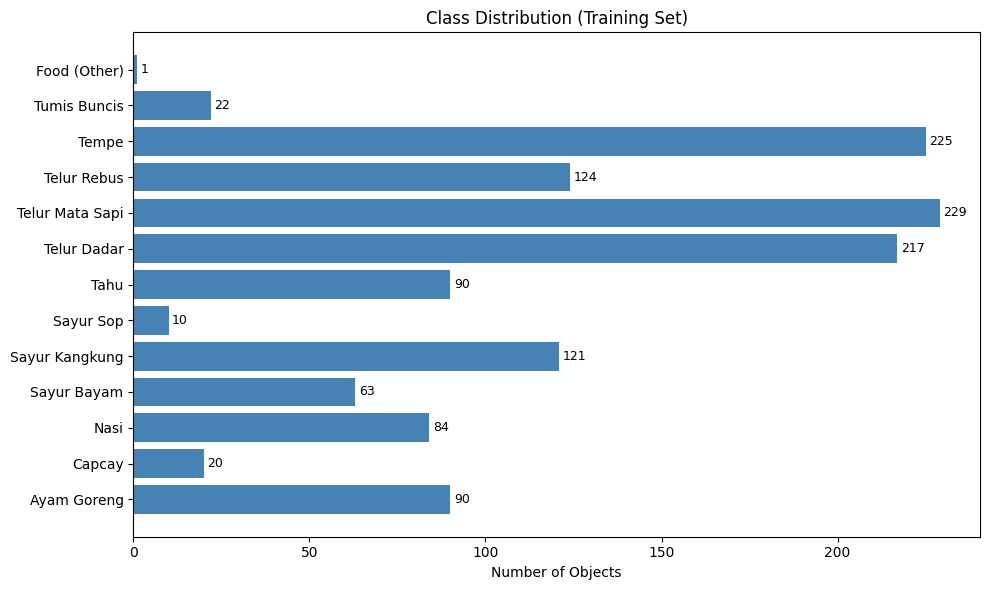

In [9]:
# count class distribution from label files
def count_distribution(label_dir):
    class_counts = Counter()
    for label_file in glob.glob(os.path.join(label_dir, '*.txt')):
        with open(label_file, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 5:
                    class_counts[int(parts[0])] += 1
    return class_counts

train_dist = count_distribution(os.path.join(DATASET_DIR, 'train', 'labels'))

# plot class distribution
classes = [SHORT_NAMES[k] for k in sorted(train_dist.keys())]
counts = [train_dist[k] for k in sorted(train_dist.keys())]

plt.figure(figsize=(10, 6))
plt.barh(classes, counts, color='steelblue')
plt.xlabel('Number of Objects')
plt.title('Class Distribution (Training Set)')
for i, v in enumerate(counts):
    plt.text(v + 1, i, str(v), va='center', fontsize=9)
plt.tight_layout()
plt.show()

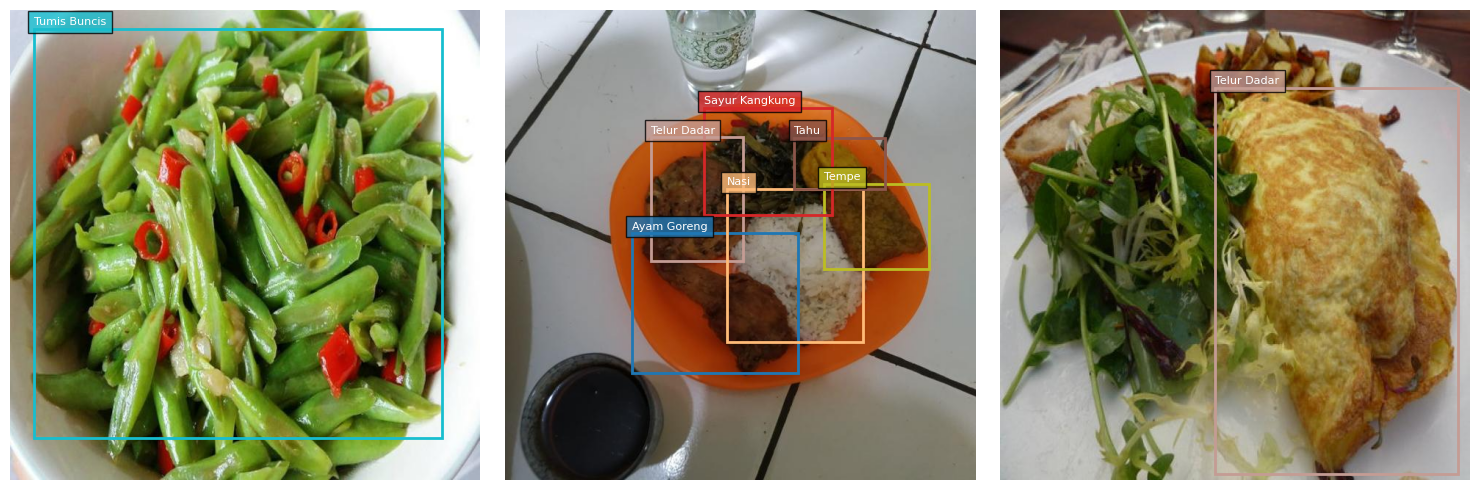

In [10]:
# display sample images with bounding boxes
def visualize_sample(image_dir, label_dir, num_samples=3):
    image_files = glob.glob(os.path.join(image_dir, '*.*'))
    samples = random.sample(image_files, min(num_samples, len(image_files)))

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    colors = plt.cm.tab20(np.linspace(0, 1, 13))

    for idx, img_path in enumerate(samples):
        img = Image.open(img_path)
        axes[idx].imshow(img)

        label_name = os.path.splitext(os.path.basename(img_path))[0] + '.txt'
        label_path = os.path.join(label_dir, label_name)

        if os.path.exists(label_path):
            w, h = img.size
            with open(label_path, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) >= 5:
                        cls_id = int(parts[0])
                        cx, cy, bw, bh = float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
                        x1 = (cx - bw/2) * w
                        y1 = (cy - bh/2) * h
                        box_w, box_h = bw * w, bh * h

                        rect = patches.Rectangle((x1, y1), box_w, box_h,
                                                 linewidth=2, edgecolor=colors[cls_id], facecolor='none')
                        axes[idx].add_patch(rect)
                        axes[idx].text(x1, y1-5, SHORT_NAMES.get(cls_id, str(cls_id)),
                                       fontsize=8, color='white',
                                       bbox=dict(facecolor=colors[cls_id], alpha=0.8))
        axes[idx].axis('off')
    plt.tight_layout()
    plt.show()

visualize_sample(
    os.path.join(DATASET_DIR, 'train', 'images'),
    os.path.join(DATASET_DIR, 'train', 'labels')
)

## 6. Training YOLOv12 Model

In [11]:
import yaml
from ultralytics import YOLO

# update paths in data.yaml to match current environment
yaml_path = os.path.join(DATASET_DIR, 'data.yaml')
with open(yaml_path, 'r') as f:
    data_config = yaml.safe_load(f)

data_config['train'] = os.path.join(DATASET_DIR, 'train', 'images')
data_config['val'] = os.path.join(DATASET_DIR, 'valid', 'images')
data_config['test'] = os.path.join(DATASET_DIR, 'test', 'images')

with open(yaml_path, 'w') as f:
    yaml.dump(data_config, f)

print('data.yaml has been updated')

# load pretrained model
model = YOLO('yolo12n.pt')
print('YOLOv12 Nano model loaded successfully')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
data.yaml has been updated
YOLOv12 Nano model loaded successfully


In [12]:
# start training
results = model.train(
    data=yaml_path,
    epochs=50,
    imgsz=640,
    batch=16,
    patience=10,
    save=True,
    project='runs/detect',
    name='calory_detection',

    # non-geometric augmentation
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,

    # disable geometric augmentation
    flipud=0.0,
    fliplr=0.0,
    degrees=0.0,

    mosaic=1.0
)
print('Training complete!')

Ultralytics 8.4.62 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/07. AI/object_detection_calory/Calory.v1i.yolov12/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo12n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=calory_detection, nbs=64, nms=False, opset=None, 

## 7. Model Evaluation

In [13]:
# evaluate on validation set
val_metrics = model.val(data=yaml_path, split='val')
print(f'Validation mAP50   : {val_metrics.box.map50:.4f}')
print(f'Validation mAP50-95: {val_metrics.box.map:.4f}')

Ultralytics 8.4.62 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv12n summary (fused): 159 layers, 2,559,263 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 3.3±5.4 ms, read: 18.6±11.5 MB/s, size: 48.3 KB)
val: Scanning /content/drive/MyDrive/07. AI/object_detection_calory/Calory.v1i.yolov12/valid/labels.cache... 147 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 147/147 61.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 2.6it/s 3.8s
                   all        147        173      0.863      0.826      0.907      0.655
Capcay -67 kal per 100gr-          8          8      0.964          1      0.995       0.85
Sayur kangkung -98 kal per 100gr-         23         23      0.956      0.955      0.986      0.602
Tahu -80 kal per 100 gr-          1          2          1      0.966      0.995      0.746
Telur Dadar -93 kal per 100gr-         50         56      0.815  

In [14]:
# evaluate on test set
test_metrics = model.val(data=yaml_path, split='test')
print(f'Test mAP50   : {test_metrics.box.map50:.4f}')
print(f'Test mAP50-95: {test_metrics.box.map:.4f}')

Ultralytics 8.4.62 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.7±0.3 ms, read: 7.6±16.3 MB/s, size: 71.0 KB)
val: Scanning /content/drive/MyDrive/07. AI/object_detection_calory/Calory.v1i.yolov12/test/labels... 106 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 106/106 2.7it/s 39.3s
val: New cache created: /content/drive/MyDrive/07. AI/object_detection_calory/Calory.v1i.yolov12/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 2.1it/s 3.4s
                   all        106        126      0.695      0.833      0.816      0.554
Capcay -67 kal per 100gr-          6          6      0.829          1      0.995      0.818
Sayur kangkung -98 kal per 100gr-         10         10       0.78          1      0.995      0.665
Tahu -80 kal per 100 gr-          2          3      0.736          1       0.83      0.361
Telur Dadar -93 kal per 100gr-         50    

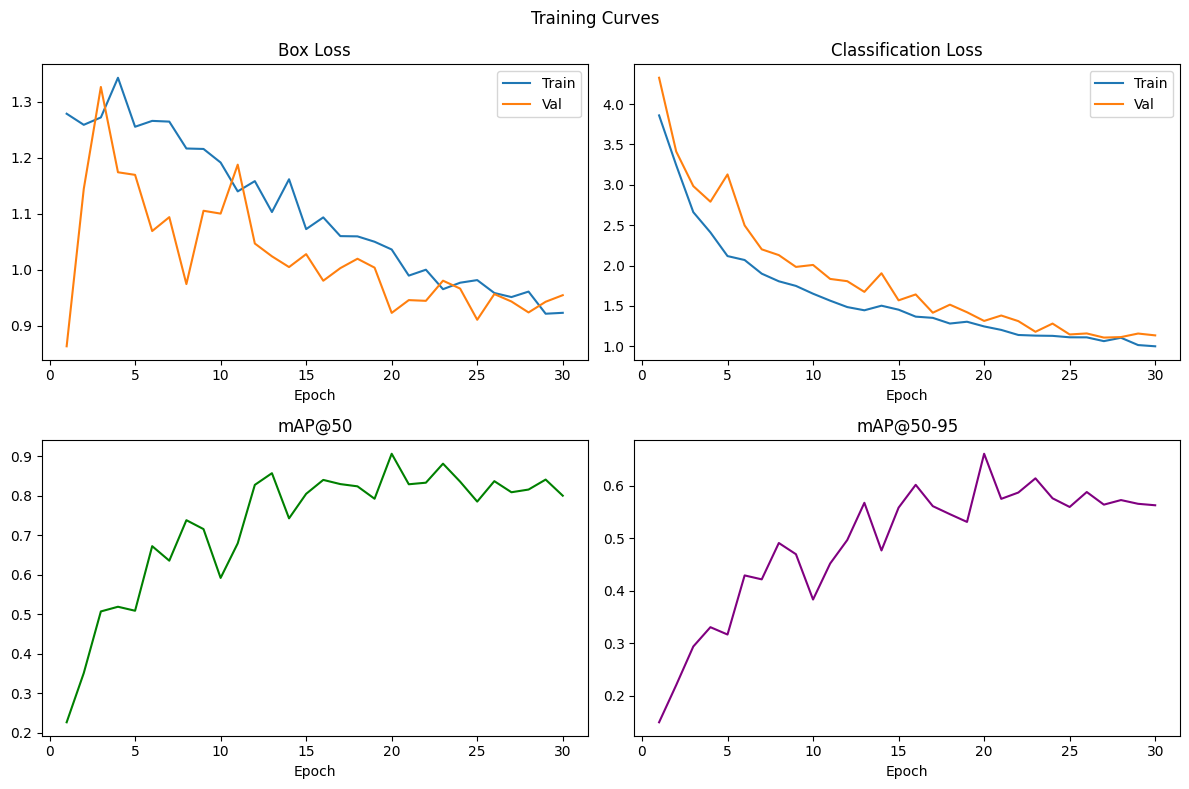

In [17]:
# plot training curves
import pandas as pd

results_csv = '/content/runs/detect/runs/detect/calory_detection/results.csv'

if os.path.exists(results_csv):
    df = pd.read_csv(results_csv)
    df.columns = df.columns.str.strip()

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))

    axes[0,0].plot(df['epoch'], df['train/box_loss'], label='Train')
    axes[0,0].plot(df['epoch'], df['val/box_loss'], label='Val')
    axes[0,0].set_title('Box Loss')
    axes[0,0].legend()

    axes[0,1].plot(df['epoch'], df['train/cls_loss'], label='Train')
    axes[0,1].plot(df['epoch'], df['val/cls_loss'], label='Val')
    axes[0,1].set_title('Classification Loss')
    axes[0,1].legend()

    axes[1,0].plot(df['epoch'], df['metrics/mAP50(B)'], color='green')
    axes[1,0].set_title('mAP@50')

    axes[1,1].plot(df['epoch'], df['metrics/mAP50-95(B)'], color='purple')
    axes[1,1].set_title('mAP@50-95')

    for ax in axes.flat:
        ax.set_xlabel('Epoch')

    plt.suptitle('Training Curves')
    plt.tight_layout()
    plt.show()
else:
    print(f'File not found: {results_csv}')

## 8. Food Detection & Calorie Estimation Demo

Detection Results:
  Telur Dadar x1 = 93 kcal
Total Estimated Calories: 93 kcal


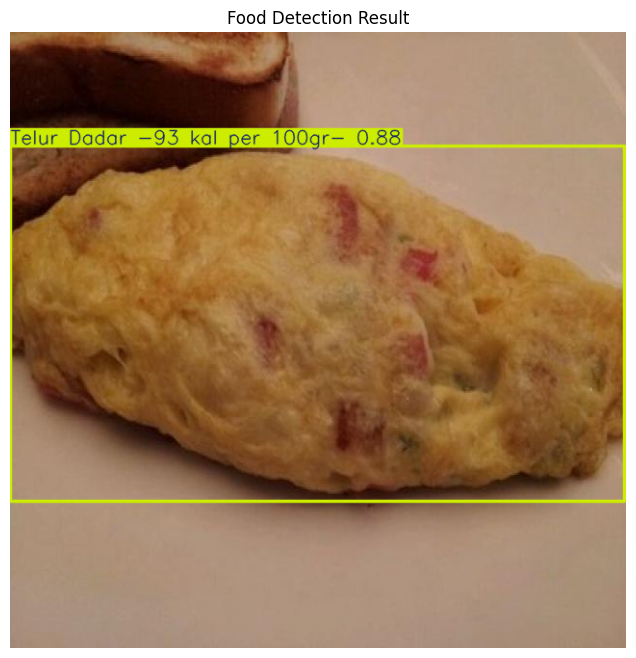

In [19]:
def analyze_calories(image_path):
    """Detect food in the image and calculate total calories."""
    results = model.predict(image_path, conf=0.25, verbose=False)
    res = results[0]

    food_count = Counter()
    total_cal = 0

    if res.boxes is not None:
        for box in res.boxes:
            cls_id = int(box.cls[0])
            name = SHORT_NAMES.get(cls_id, 'Food')
            cal = CALORY_MAP.get(cls_id, 0)
            food_count[name] += 1
            total_cal += cal

    print('Detection Results:')
    for food, count in food_count.items():
        idx = list(SHORT_NAMES.values()).index(food)
        print(f'  {food} x{count} = {CALORY_MAP[idx] * count} kcal')
    print(f'Total Estimated Calories: {total_cal} kcal')

    # display detection result image
    plt.figure(figsize=(8, 8))
    plt.imshow(cv2.cvtColor(res.plot(), cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title('Food Detection Result')
    plt.show()

# pick a random image from test set
test_images = glob.glob(os.path.join(DATASET_DIR, 'test', 'images', '*.*'))
analyze_calories(random.choice(test_images))

## 9. Save Model

In [21]:
import shutil

best_path = '/content/runs/detect/runs/detect/calory_detection/weights/best.pt'

if os.path.exists(best_path):
    shutil.copy(best_path, 'best.pt')
    print(f'Model saved successfully!. Size: {os.path.getsize("best.pt") / 1024 / 1024:.1f} MB')
    files.download('best.pt')
else:
    print(f'File not found: {best_path}')

Model saved successfully!. Size: 5.3 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>